# Waterfall Build-up — Incremental Component Analysis

This notebook visualises the Pareto front progression as the algorithmic pipeline grows from:

1. Random Search
2. MOEA/D + GA
3. MOEA/D + GA + PSO
4. MOEA/D + GA + PSO + SA

All four runs use **seed=42**, **budget=2000 NFE**, **hardware=edgegpu_latency**, **dataset=cifar10**.

In [5]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    raise FileNotFoundError("Unable to locate the repository root for HW-NAS-Memetic.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.data_processing import get_project_root
assert get_project_root() == PROJECT_ROOT


import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from src.analysis.data_loader import load_archive, load_incremental_archive
from src.utils.pareto_math import to_display, normalise_to_bounds
from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd,
)



In [6]:
stages_data = []
archives = []
for fname, label, color in STAGES:
    archive = load_archive(RESULTS_DIR, fname)
    pts = archive_to_points(archive)
    front = get_pareto_front(pts)
    archives.append(archive)
    acc, lat = to_display(front)
    stages_data.append({
        "label": label,
        "color": color,
        "archive": archive,
        "front": front,
        "acc": acc,
        "lat": lat,
    })
    print(f"{label}: {len(acc)} Pareto points | acc=[{acc.min():.2f}, {acc.max():.2f}] | lat=[{lat.min():.2f}, {lat.max():.2f}]")

all_points = np.vstack([get_pareto_front(archive_to_points(a)) for a in archives])
proxy_front = get_pareto_front(all_points)
min_val = all_points.min(axis=0)
max_val = all_points.max(axis=0)
scale = np.where(max_val - min_val > 0, max_val - min_val, 1.0)

proxy_norm = normalise_to_bounds(proxy_front, min_val, scale)

stage_metrics = []
for stage in stages_data:
    norm_front = normalise_to_bounds(stage["front"], min_val, scale)
    hv = calc_hv(norm_front, ref_point=REF)
    igd = calc_igd(norm_front, proxy_norm)
    best_acc_lt2 = float(stage["acc"][stage["lat"] < 2.0].max()) if np.any(stage["lat"] < 2.0) else np.nan
    best_lat_gt90 = float(stage["lat"][stage["acc"] > 90.0].min()) if np.any(stage["acc"] > 90.0) else np.nan
    stage_metrics.append({
        "Stage": stage["label"],
        "HV": hv,
        "IGD": igd,
        "Best Accuracy @ Latency < 2ms": best_acc_lt2,
        "Best Latency @ Accuracy > 90%": best_lat_gt90,
        "Pareto Points": len(stage["acc"]),
    })

metrics_df = pd.DataFrame(stage_metrics)
metrics_df["ΔHV"] = metrics_df["HV"].diff().fillna(0.0)
metrics_df["ΔIGD Improvement"] = (-metrics_df["IGD"].diff()).fillna(0.0)

metrics_df


Stage 1: Random: 13 Pareto points | acc=[10.00, 94.22] | lat=[0.54, 6.86]
Stage 2: +MOEA/D + GA: 144 Pareto points | acc=[10.00, 94.25] | lat=[0.54, 6.50]
Stage 3: +PSO: 108 Pareto points | acc=[10.00, 94.36] | lat=[0.50, 7.05]
Stage 4: +SA (Full): 293 Pareto points | acc=[10.00, 94.37] | lat=[0.50, 6.81]


,Stage,HV,IGD,Best Accuracy @ Latency < 2ms,Best Latency @ Accuracy > 90%,Pareto Points,ΔHV,ΔIGD Improvement
0,Stage 1: Random,1.054370,0.004809,92.276665,1.754365,13,0.000000,0.000000
1,Stage 2: +MOEA/D + GA,1.054952,0.004923,92.245003,1.738467,144,0.000583,-0.000114
2,Stage 3: +PSO,1.053812,0.004919,92.190002,1.738467,108,-0.001140,0.000004
3,Stage 4: +SA (Full),1.055057,0.000371,92.504997,1.764450,293,0.001244,0.004549


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/waterfall_sweep_grid.pdf


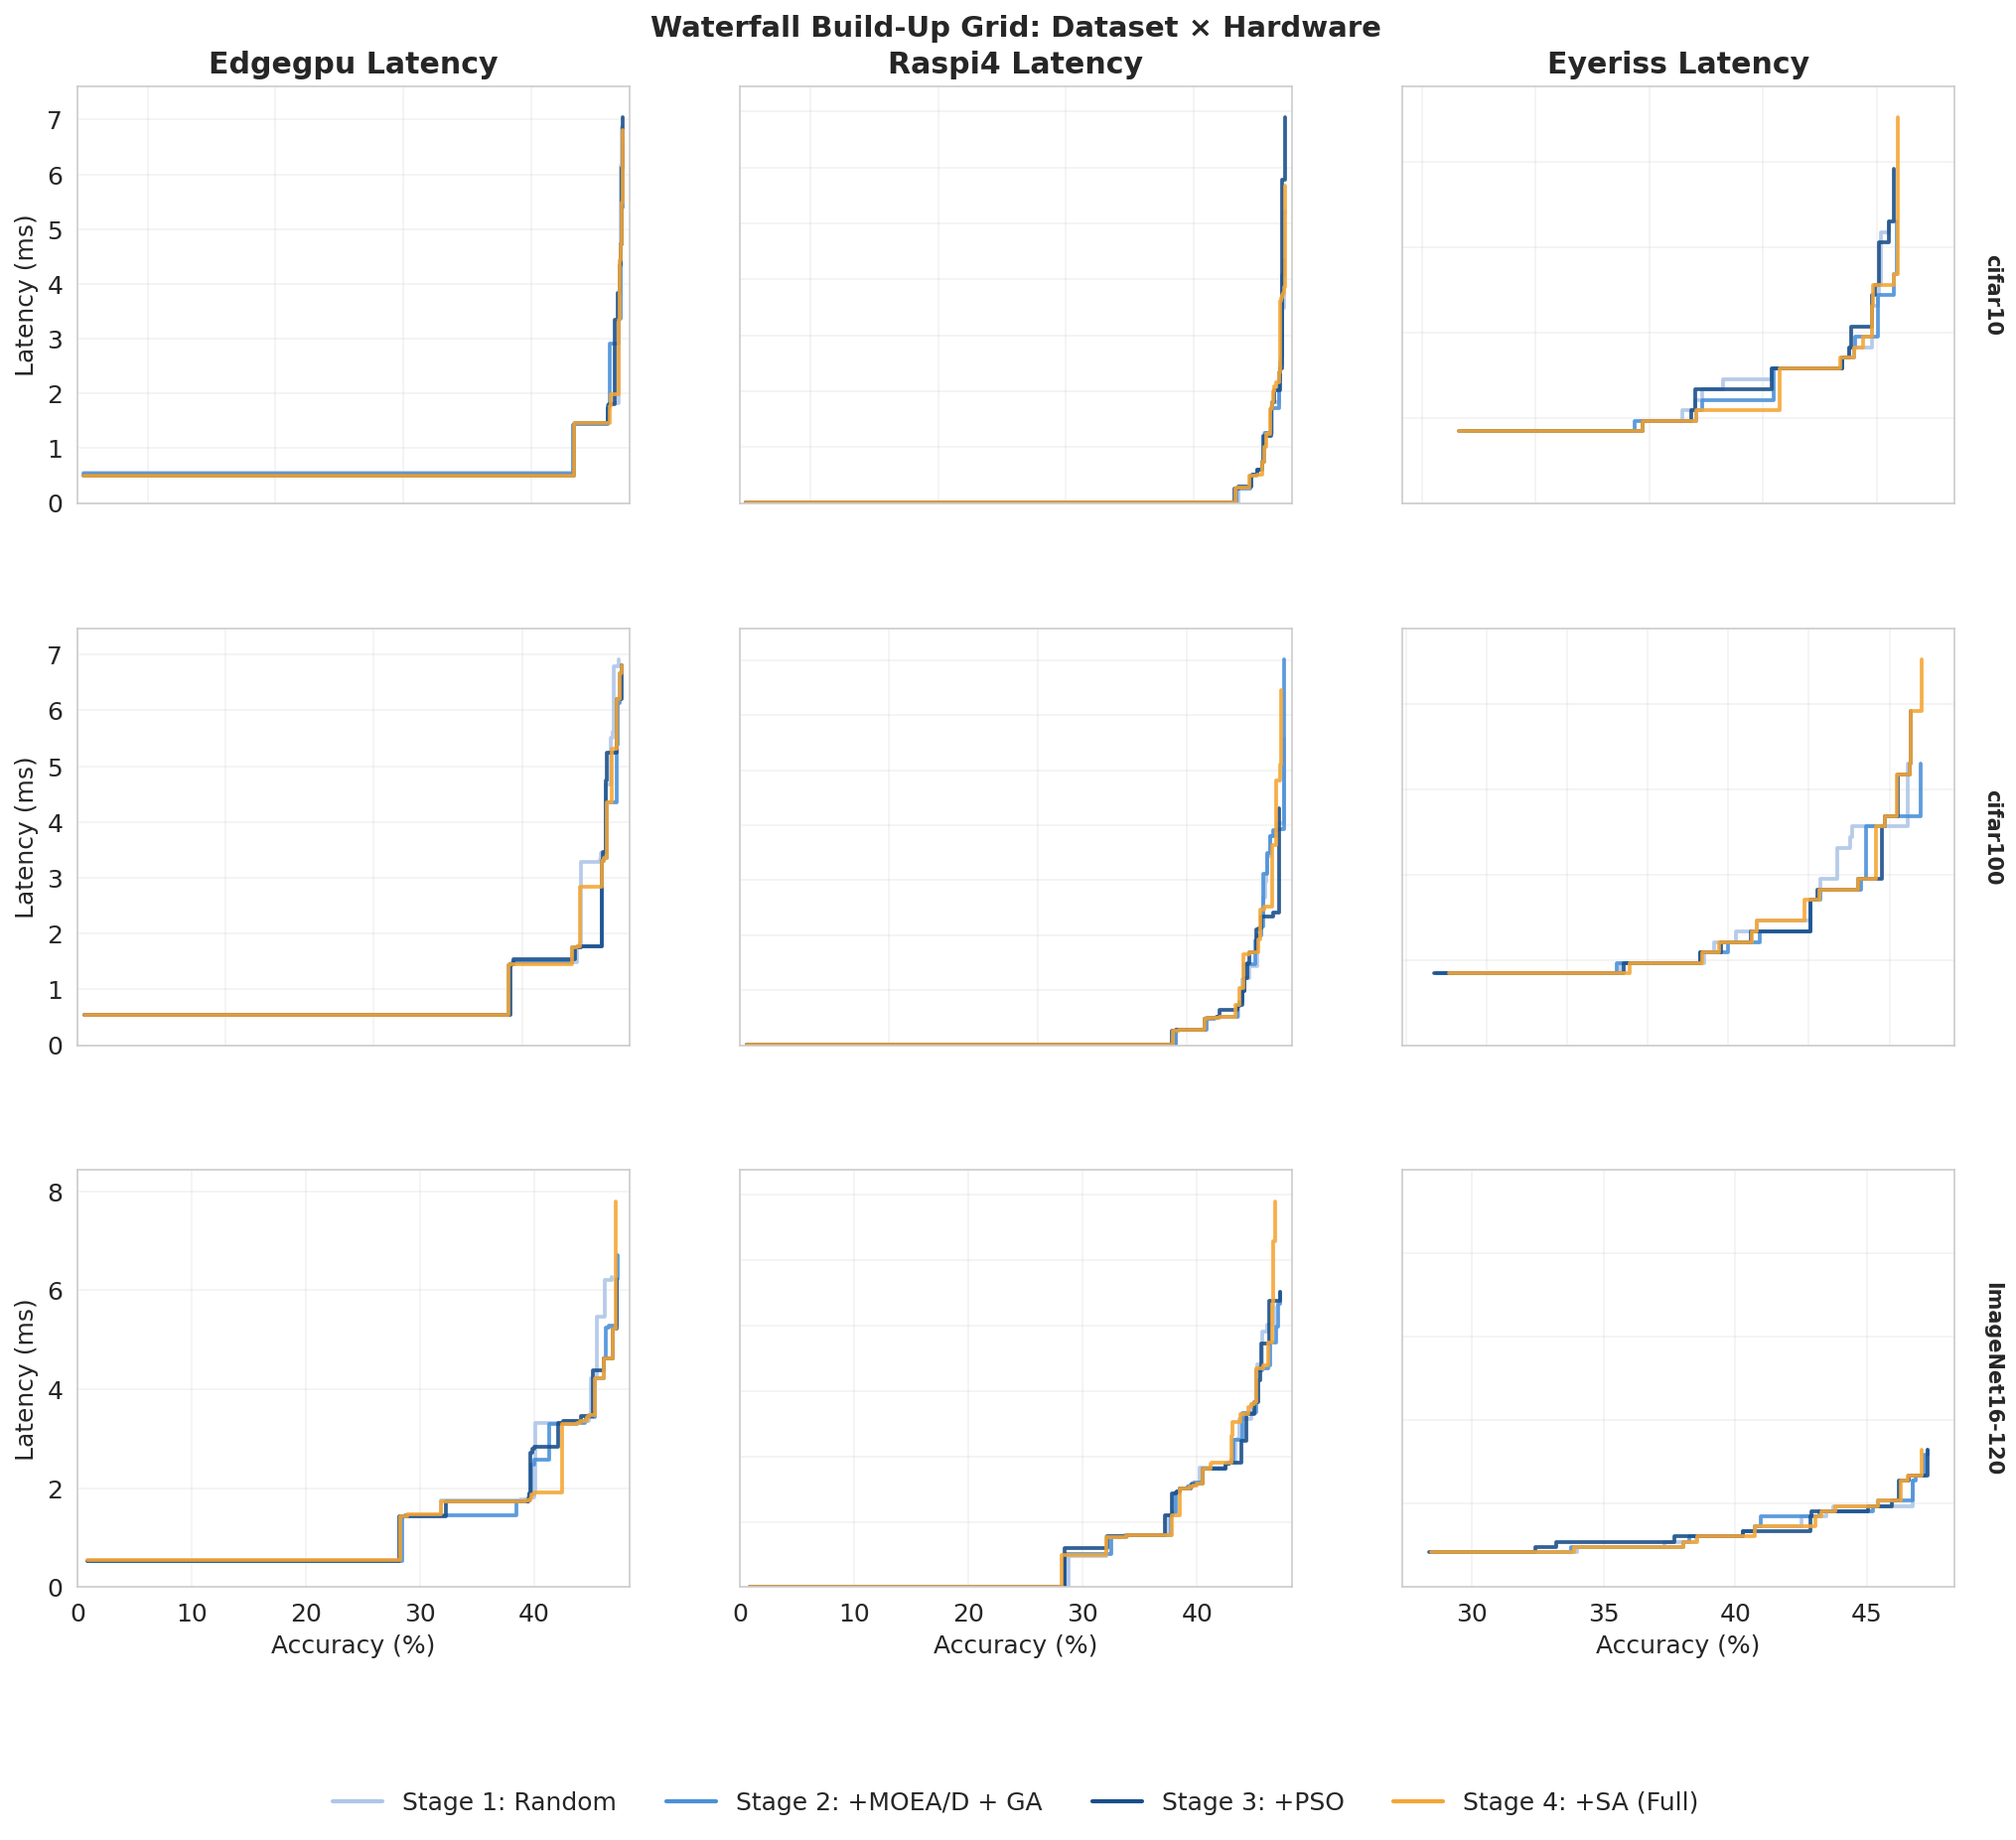

In [9]:
# ── 3×3 Sweep Grid: Incremental Build Across Datasets and Hardware Targets
fig, axes = plt.subplots(
    nrows=len(DATASETS),
    ncols=len(HARDWARE),
    figsize=(5 * len(HARDWARE), 4 * len(DATASETS)),
)

missing = []
for row_idx, dataset in enumerate(DATASETS):
    for col_idx, hardware in enumerate(HARDWARE):
        ax = axes[row_idx][col_idx]
        combo_dir = RESULTS_BASE / dataset / hardware
        if not combo_dir.exists():
            ax.text(
                0.5, 0.5,
                f"Missing data:\n{dataset}/{hardware}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
                color="grey",
            )
            ax.set_xticks([])
            ax.set_yticks([])
            missing.append(f"{dataset}/{hardware}")
            continue

        y_vals = []
        acc_vals = []
        any_found = False
        for fname, label, color in STAGES:
            try:
                archive = load_incremental_archive(dataset, hardware, fname)
            except FileNotFoundError:
                continue
            any_found = True
            pts = archive_to_points(archive)
            front = get_pareto_front(pts)
            acc, lat = to_display(front)
            y_vals.append(lat.max())
            acc_vals.append(acc.min())
            acc_vals.append(acc.max())
            ax.step(
                acc,
                lat,
                where="post",
                label=label,
                color=color,
                linewidth=1.8,
                alpha=0.9,
            )

        if not any_found:
            ax.text(
                0.5, 0.5,
                f"No stage results\nfor {dataset}/{hardware}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
                color="grey",
            )
            ax.set_xticks([])
            ax.set_yticks([])
            missing.append(f"{dataset}/{hardware}")
            continue

        x_min = max(0, min(acc_vals) - 1)
        x_max = min(100, max(acc_vals) + 1)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, max(5.0, max(y_vals) * 1.08))
        if row_idx == len(DATASETS) - 1:
            ax.set_xlabel("Accuracy (%)")
        else:
            ax.set_xticklabels([])

        if col_idx == 0:
            ax.set_ylabel("Latency (ms)")
        else:
            ax.set_yticklabels([])

        if row_idx == 0:
            ax.set_title(hardware.replace("_", " ").title(), fontweight="bold")

        if col_idx == len(HARDWARE) - 1:
            ax.annotate(
                dataset,
                xy=(1.05, 0.5),
                xycoords="axes fraction",
                fontsize=10,
                fontweight="bold",
                ha="left",
                va="center",
                rotation=-90,
            )
        ax.grid(True, alpha=0.25)

legend_handles = [
    mlines.Line2D([], [], color=color, linewidth=2.0, label=label)
    for _, label, color in STAGES
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(STAGES),
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle("Waterfall Build-Up Grid: Dataset × Hardware", fontsize=14, fontweight="bold", y=0.98)
fig.subplots_adjust(left=0.08, right=0.92, top=0.94, bottom=0.10, hspace=0.30, wspace=0.20)

grid_path = FIGURES_DIR / "waterfall_sweep_grid.pdf"
fig.savefig(grid_path, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "waterfall_sweep_grid.png", bbox_inches="tight")
print(f"Saved → {grid_path}")
if missing:
    print(f"Missing combos: {', '.join(missing)}")

plt.show()


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/waterfall_pareto_overlay.pdf


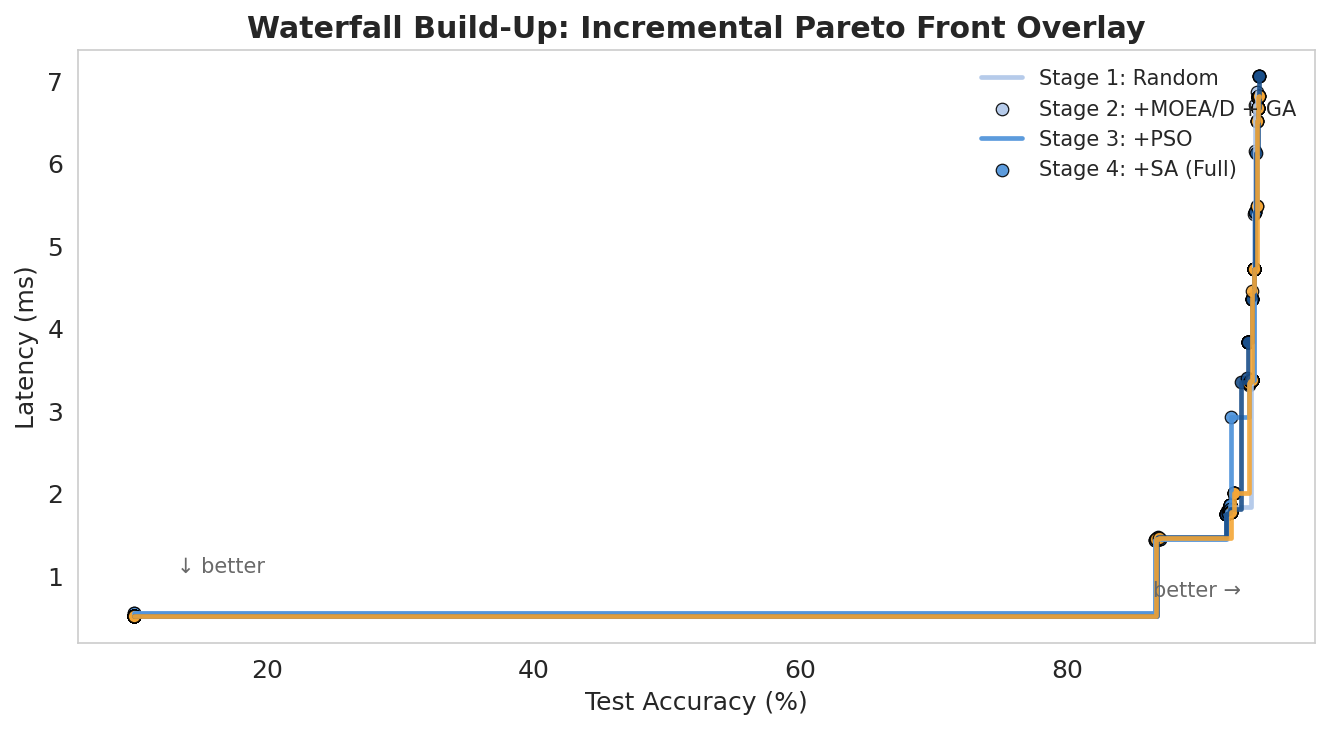

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/stage_hv_progression.pdf


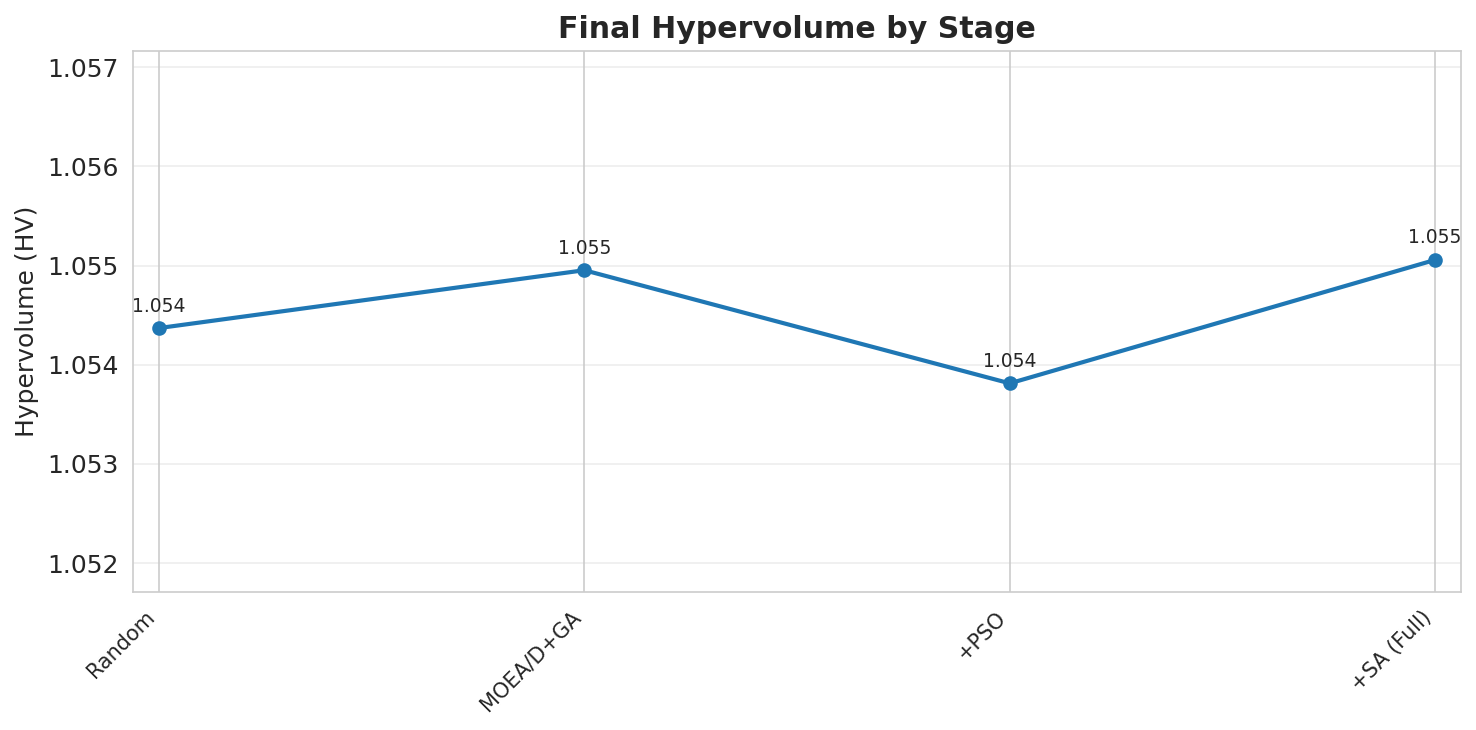

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/stage_igd_progression.pdf


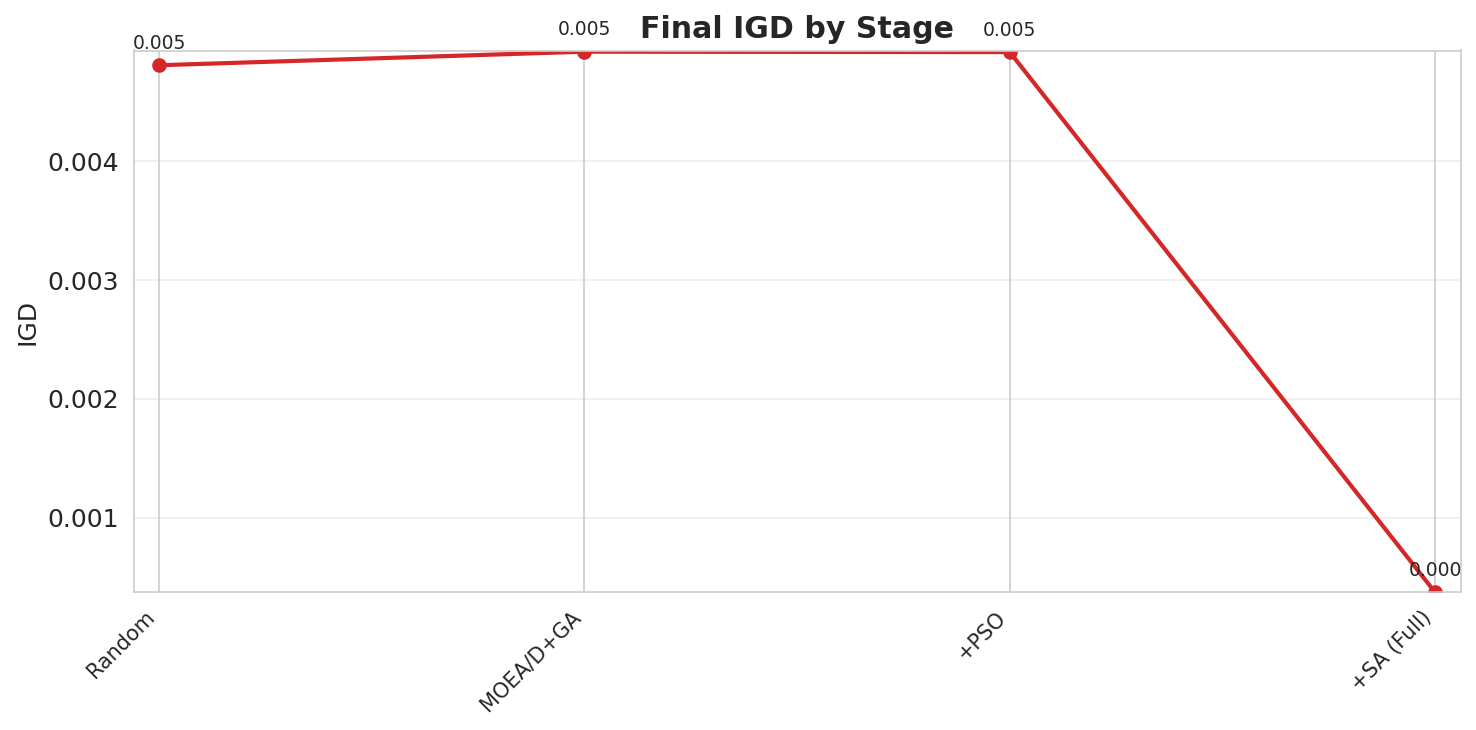

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for stage in stages_data:
    ax.step(stage["acc"], stage["lat"], where="post", color=stage["color"], linewidth=2.25, alpha=0.9)
    ax.scatter(stage["acc"], stage["lat"], color=stage["color"], s=36, edgecolors="black", linewidth=0.6, alpha=0.9)

ax.set_xlabel("Test Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Waterfall Build-Up: Incremental Pareto Front Overlay", fontweight="bold")
ax.legend([stage["label"] for stage in stages_data], frameon=False, fontsize=10, loc="upper right")
ax.annotate("better →", xy=(0.94, 0.08), xycoords="axes fraction", ha="right", fontsize=10, color="dimgray")
ax.annotate("↓ better", xy=(0.08, 0.12), xycoords="axes fraction", ha="left", fontsize=10, color="dimgray")
ax.grid(False)
fig.tight_layout(pad=1.0)
out_path = PROJECT_ROOT / "results" / "incremental" / "waterfall_pareto_overlay.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

stage_labels = [
    "Random",
    "MOEA/D+GA",
    "+PSO",
    "+SA (Full)",
]
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(stage_labels, metrics_df["HV"], marker="o", linewidth=2.0, color="#1f77b4")
ax2.set_title("Final Hypervolume by Stage", fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("Hypervolume (HV)")
ax2.grid(axis="y", alpha=0.35)
ax2.set_xticks(stage_labels)
ax2.set_xticklabels(stage_labels, rotation=45, ha="right", fontsize=10)
ax2.tick_params(axis="x", labelsize=10)
ax2.margins(x=0.02)
ax2.set_ylim(metrics_df["HV"].min() * 0.998, metrics_df["HV"].max() * 1.002)
for x, y in zip(stage_labels, metrics_df["HV"]):
    ax2.annotate(
        f"{y:.3f}",
        xy=(x, y),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig2.tight_layout(pad=1.0)
out_path = PROJECT_ROOT / "results" / "incremental" / "stage_hv_progression.pdf"
fig2.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(stage_labels, metrics_df["IGD"], marker="o", linewidth=2.0, color="#d62728")
ax3.set_title("Final IGD by Stage", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("IGD")
ax3.grid(axis="y", alpha=0.35)
ax3.set_xticks(stage_labels)
ax3.set_xticklabels(stage_labels, rotation=45, ha="right", fontsize=10)
ax3.tick_params(axis="x", labelsize=10)
ax3.margins(x=0.02)
ax3.set_ylim(metrics_df["IGD"].min() * 0.998, metrics_df["IGD"].max() * 1.002)
for x, y in zip(stage_labels, metrics_df["IGD"]):
    ax3.annotate(
        f"{y:.3f}",
        xy=(x, y),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )
fig3.tight_layout(pad=1.0)
out_path = PROJECT_ROOT / "results" / "incremental" / "stage_igd_progression.pdf"
fig3.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()
